# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [1]:
%pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [2]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 28.3 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


### Import Statements

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [5]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [6]:
df_data.shape

(4324, 9)

In [7]:

df_data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

In [8]:
df_data.duplicated().values.any()

np.False_

## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data.

In [9]:
df_data.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [10]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


In [11]:
data_clean = df_data.drop(["Unnamed: 0", "Unnamed: 0.1"], axis=1)
data_clean.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


## Descriptive Statistics

In [12]:
data_clean.describe()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,4324,4324,4324,4324,4324,964,4324
unique,56,137,4319,4278,2,56,4
top,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Tue Aug 28, 1990 09:05 UTC",Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,450.0,Success
freq,1777,235,2,6,3534,136,3879


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [13]:
top_organisations = data_clean["Organisation"].value_counts().head(10)

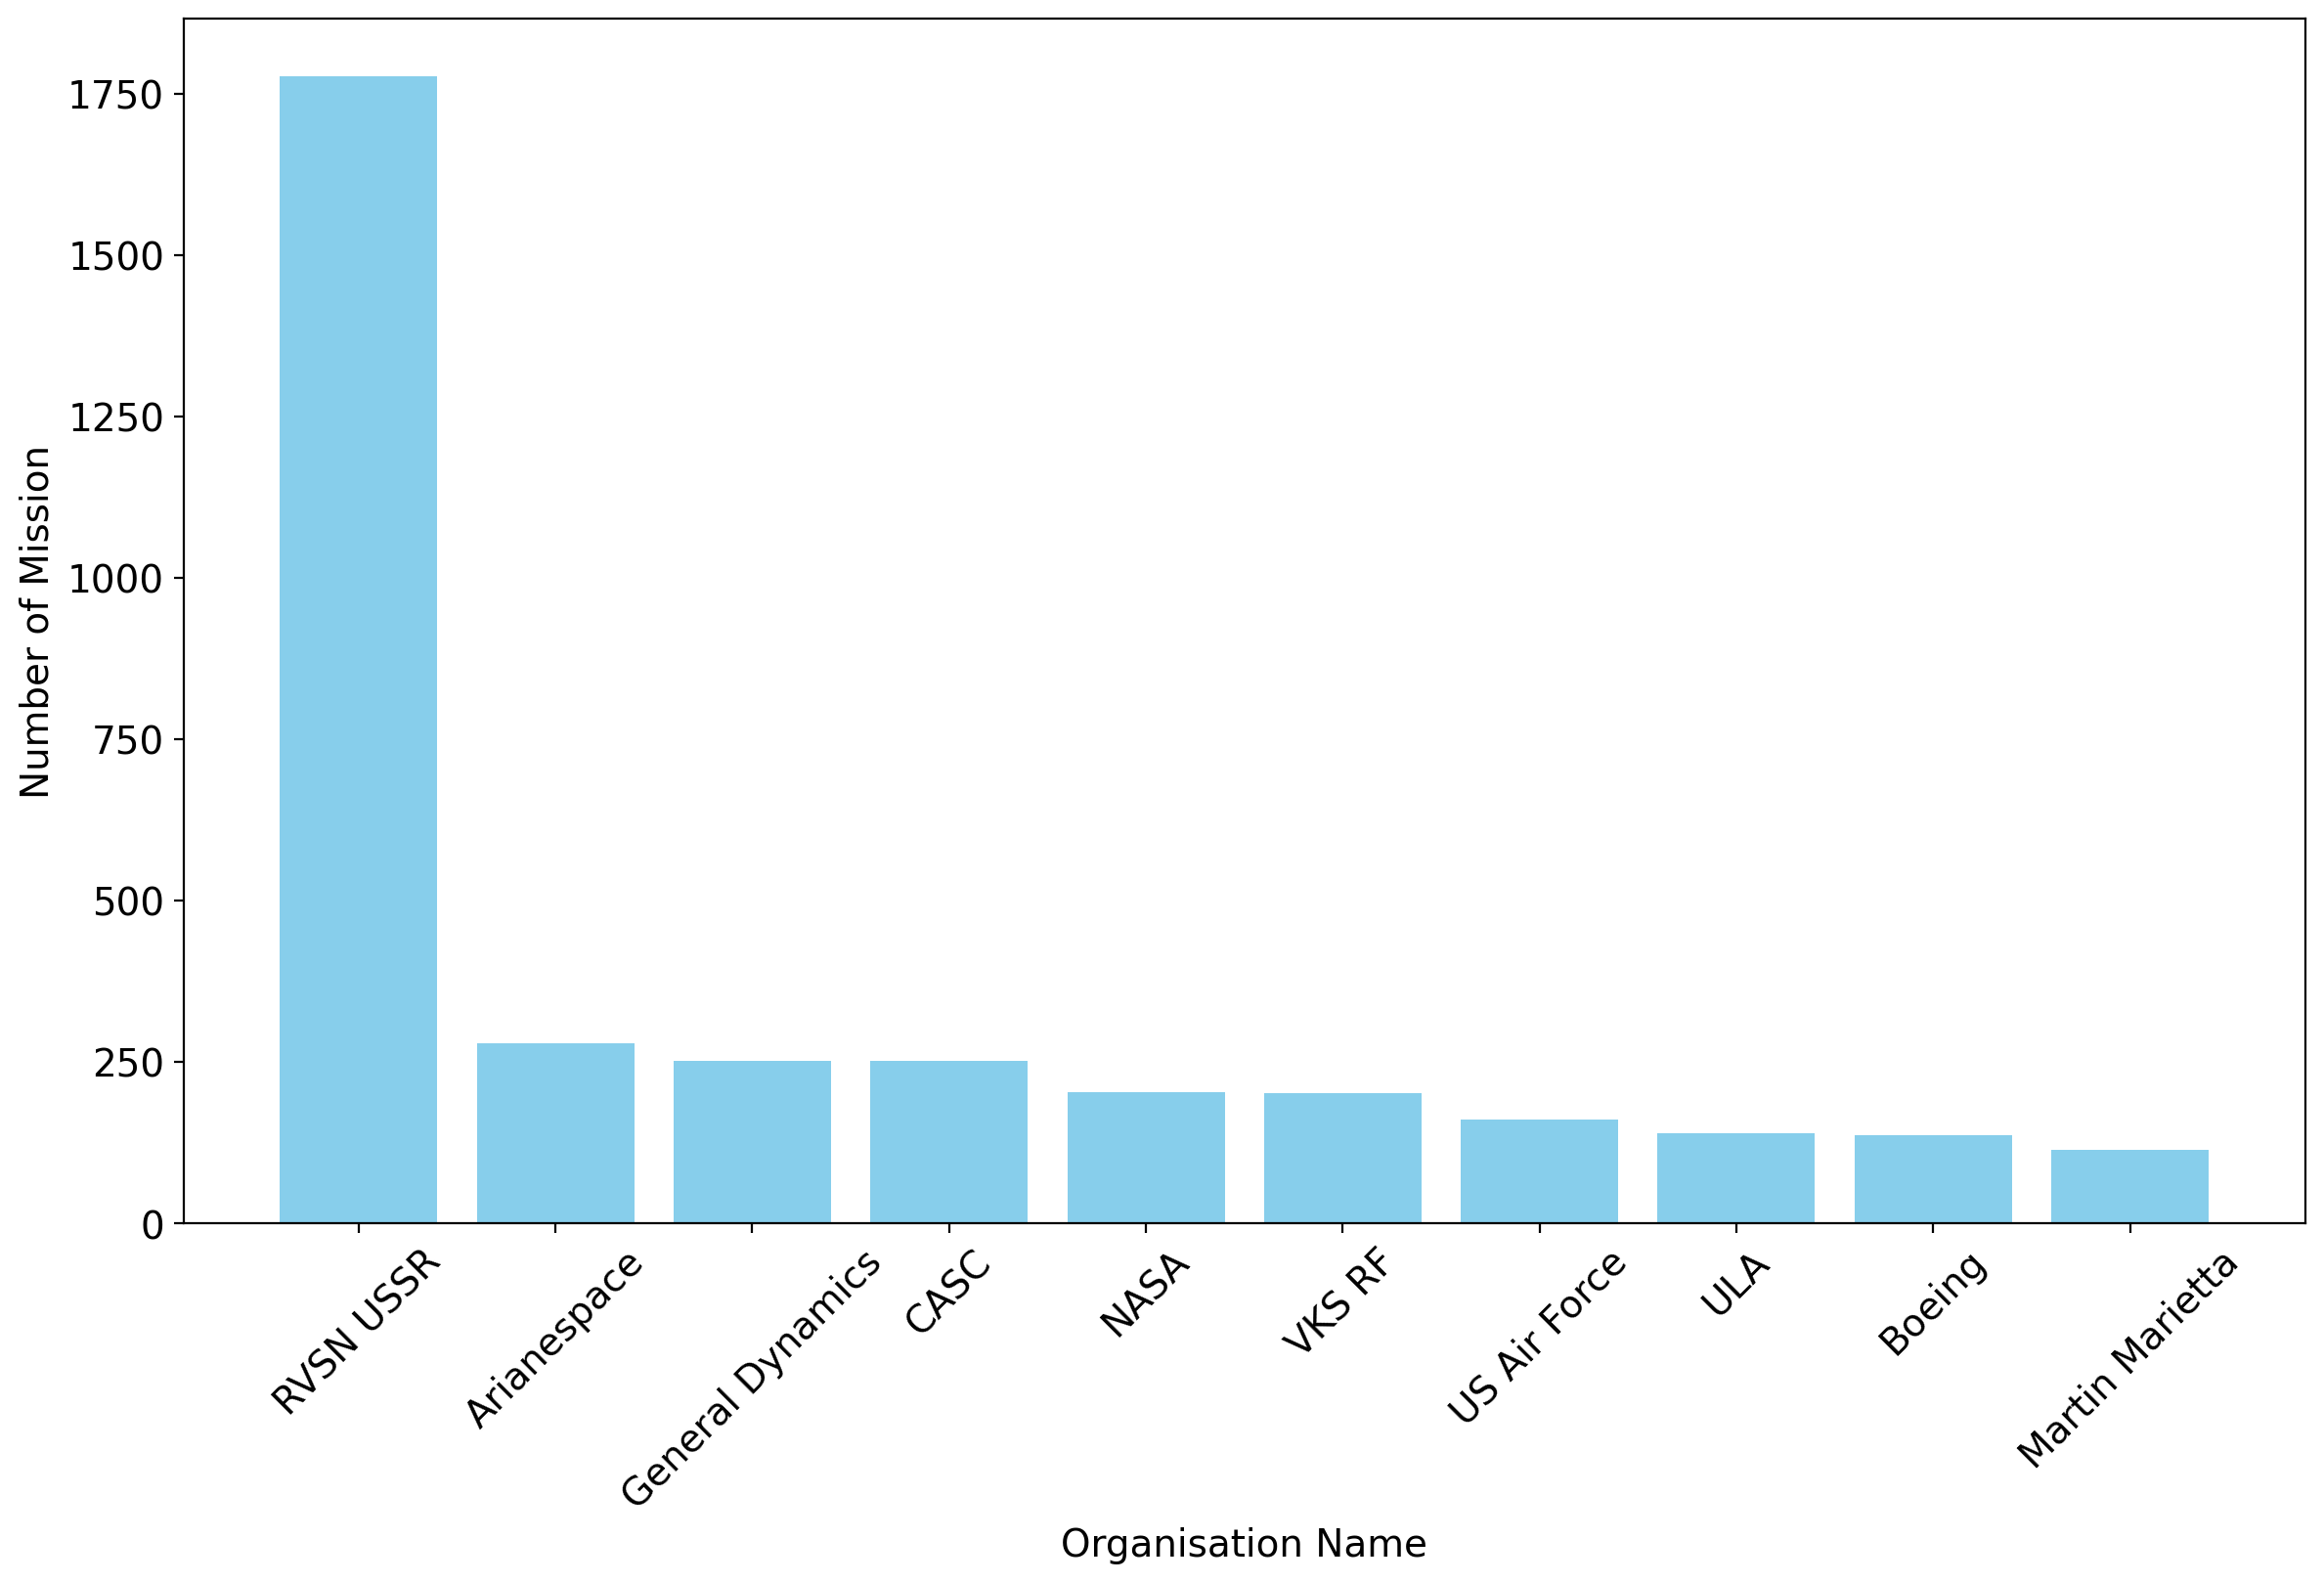

In [14]:
plt.figure(figsize=(14, 8), dpi=200)
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)
plt.xlabel("Organisation Name", fontsize=14)
plt.ylabel("Number of Mission", fontsize=14)
plt.bar(top_organisations.index, top_organisations.values, color="skyblue")
plt.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned?

In [15]:
status = data_clean['Rocket_Status'].value_counts()

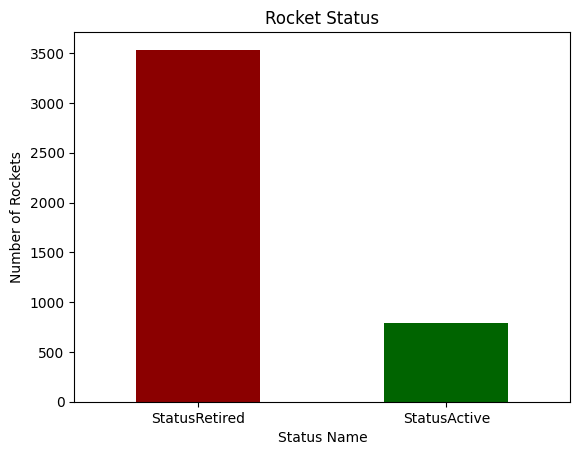

In [16]:
status.plot(kind="bar", color=["darkred", "darkgreen"])
plt.title("Rocket Status")
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Status Name", fontsize=10)
plt.ylabel("Number of Rockets",fontsize=10)
plt.show()

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [17]:
mission_status = data_clean['Mission_Status'].value_counts()

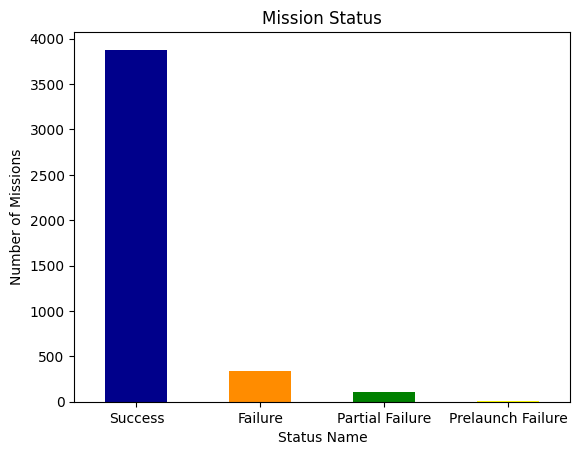

In [18]:
mission_status.plot(kind="bar", color=["darkblue", "darkorange", "green", "yellow"])
plt.title("Mission Status")
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Status Name", fontsize=10)
plt.ylabel("Number of Missions", fontsize=10)
plt.show()

# How Expensive are the Launches?

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values).

In [19]:
data_clean['Price'] = data_clean['Price'].str.replace(', ', " ")
data_clean['Price'] = pd.to_numeric(data_clean['Price'], errors='coerce')


Text(0, 0.5, 'Number of Missions')

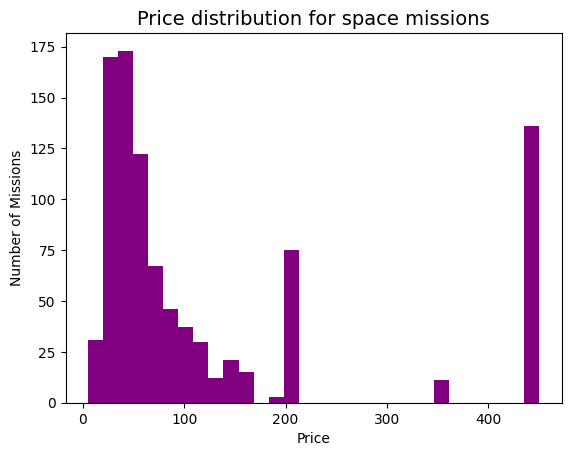

In [20]:
plt.hist(data_clean['Price'].dropna(), bins=30, color="purple")
plt.title("Price distribution for space missions", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Price", fontsize=10)
plt.ylabel("Number of Missions", fontsize=10)

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [21]:
data_clean.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success


In [22]:
country_name = data_clean["Location"].str.split(", ").str[-1]
data_clean['Country'] = country_name
fixes = {
    'Russia': 'Russian Federation',
    'Barents Sea': 'Russian Federation',
    'New Mexico': 'USA',
    'Pacific Missile Range Facility': 'USA',
    'Gran Canaria': 'USA',
    'Yellow Sea': 'China',
    'Shahrud Missile Test Site': 'Iran'
}
data_clean['Country'] = data_clean['Country'].replace(fixes)

In [23]:
codes = []

for country in data_clean["Country"]:
  if country == "USA":
    codes.append('USA')
  elif country == "Iran":
    codes.append("IRN")
  elif country == "North Korea":
    codes.append("PRK")
  elif country == "South Korea":
    codes.append("KOR")
  elif country == "Pacific Ocean":
    codes.append("USA")
  else:
    library_code = countries.get(country).alpha3
    codes.append(library_code)

data_clean['ISO'] = codes

In [24]:
map_data = data_clean.groupby("ISO").size().reset_index(name="Number of Missions")
world_map = px.choropleth(map_data, locations='ISO', color='Number of Missions', color_continuous_scale="matter")
world_map.update_layout(coloraxis_showscale=True)
world_map.show()

# Use a Choropleth Map to Show the Number of Failures by Country


In [25]:
mission_failure = data_clean[data_clean['Mission_Status'] == 'Failure']

In [26]:
map_data = mission_failure.groupby('ISO').size().reset_index(name="Number of Filure Missions")
world_map = px.choropleth(map_data, locations='ISO', color='Number of Filure Missions', color_continuous_scale="matter")
world_map.update_layout(coloraxis_showscale=True)
world_map.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status.

In [27]:
data_clean.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,ISO
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,USA,USA
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China,CHN
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA,USA
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,Kazakhstan,KAZ
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success,USA,USA


In [28]:
burst = px.sunburst(data_clean, path=["Country", "Organisation", "Mission_Status"], title="Hierarchy of space missions")
burst.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [29]:
data_clean['Price'] = data_clean['Price'].astype(str).str.replace(", ", "")
data_clean['Price'] = pd.to_numeric(data_clean['Price'], errors='coerce').fillna(0)


In [30]:
organisation_spending = data_clean.groupby("Organisation")['Price'].sum().reset_index(name="Total_spent")
organisation_spending = organisation_spending.sort_values(by="Total_spent", ascending=False)

In [31]:
fig = px.bar(organisation_spending.head(15), x="Organisation", y="Total_spent")
fig.update_layout(xaxis_title="Organisation", yaxis_title="Total Spent")
fig.show()

# Analyse the Amount of Money Spent by Organisation per Launch

In [32]:
organisation_per_launch = data_clean.groupby("Organisation")['Price'].mean().reset_index(name="Average_Price_Per_Launch")
organisation_per_launch = organisation_per_launch.sort_values(by="Average_Price_Per_Launch", ascending=False)


In [33]:
fig = px.bar(organisation_per_launch.head(15), x="Organisation", y="Average_Price_Per_Launch")
fig.update_layout(xaxis_title="Organisation", yaxis_title="Average Price")
fig.show()

# Chart the Number of Launches per Year

In [34]:
data_clean["Year"] = data_clean["Date"].str.split(" ").str[3]
data_clean["Year"] = pd.to_numeric(data_clean['Year'], errors="coerce")

In [35]:
launches_per_year = data_clean.groupby("Year").size().reset_index(name="Launch_Count")
launches_per_year = launches_per_year.sort_values(by="Launch_Count", ascending=False)

In [48]:
fig = px.bar(launches_per_year, x="Year", y="Launch_Count", title="Number of Launches per Year")
fig.update_layout(xaxis_title="Year", yaxis_title="Number of Missions")
fig.show()

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart.

In [37]:
data_clean["Month"] = data_clean["Date"].str.split(" ").str[1]

In [38]:
launches_per_month = data_clean.groupby("Month").size().reset_index(name="Launch_Count")
launches_per_month = launches_per_month.sort_values(by="Launch_Count", ascending=False)

In [47]:
fig = px.bar(launches_per_month, x="Month", y="Launch_Count", title="Months with the highest number of launches")
fig.update_layout(xaxis_title="Month", yaxis_title="Number of Missions")
fig.show()

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [40]:
monthly_popularity = data_clean.groupby('Month').size().reset_index(name='Launch_Count')
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_popularity['Month'] = pd.Categorical(monthly_popularity["Month"], categories=months_order, ordered=True)
monthly_popularity = monthly_popularity.sort_values("Month")

In [46]:
fig = px.bar(monthly_popularity, x="Month", y="Launch_Count", title="The most popular months")
fig.update_layout(xaxis_title="Month", yaxis_title="Number of Missions")
fig.show()

# How has the Launch Price varied Over Time?

Create a line chart that shows the average price of rocket launches over time.

In [43]:
price_over_year = data_clean.groupby("Year")["Price"].mean().reset_index(name="Average_Price")
price_over_year = price_over_year.sort_values("Year")


In [45]:
fig = px.line(price_over_year, x="Year", y="Average_Price", title="Price varied Over Time")
fig.update_layout(xaxis_title="Year", yaxis_title="Average Price")
fig.show()

# Chart the Number of Launches over Time by the Top 10 Organisations.

How has the dominance of launches changed over time between the different players?

In [56]:
top10_organisations = data_clean["Organisation"].value_counts().head(10).index
top10_organisations = data_clean[data_clean["Organisation"].isin(top10_organisations)].copy()

In [57]:
missions_over_year = top10_organisations.groupby(["Year", "Organisation"]).size().reset_index(name="Launch_Count")
missions_over_year = missions_over_year.sort_values("Year")

In [61]:
fig = px.line(missions_over_year, x="Year", y="Launch_Count", color="Organisation", title="Number of Launches over Time by the Top 10 Organisations")
fig.update_layout(xaxis_title="Year", yaxis_title="Number of Missions")
fig.show()

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991.

In [84]:
cold_war_data = data_clean[data_clean["Year"] <= 1991].copy()
cold_war_data = cold_war_data[cold_war_data["Country"].isin(["USA", "Russian Federation"])].copy()

In [94]:
missions_over_year = cold_war_data.groupby(["Year", "Country"]).size().reset_index(name="Launch_Count")
missions_over_year = missions_over_year.sort_values("Year")

In [96]:
fig = px.line(missions_over_year, x="Year", y="Launch_Count", color="Country", title="Cold War Space Race: USA vs Russia")
fig.update_layout(xaxis_title="Year", yaxis_title="Number of Missions")
fig.show()

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches.

In [87]:
cold_war_data = data_clean[data_clean["Year"] <= 1991].copy()
cold_war_data = cold_war_data[cold_war_data["Country"].isin(["USA", "Russian Federation"])].copy()

In [89]:
missions_over_year = cold_war_data.groupby("Country").size().reset_index(name="Launch_Count")

In [91]:
fig = px.pie(labels=missions_over_year.Country, values=missions_over_year.Launch_Count, names=missions_over_year.Country, title="Total number of launches USA vs Russia")
fig.update_traces(textposition="inside", textfont_size=15 ,textinfo="percent")
fig.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [97]:
superpowers = data_clean[data_clean["Country"].isin(["USA", "Russian Federation"])].copy()

In [98]:
superpowers = superpowers.groupby("Year").size().reset_index(name="Launch_Count")
superpowers = superpowers.sort_values("Year")

In [99]:
fig = px.line(superpowers, x="Year", y="Launch_Count", title="Total Number of Launches Year-On-Year by the Two Superpowers")
fig.update_layout(xaxis_title="Year", yaxis_title="Number of Missions")
fig.show()

## Chart the Total Number of Mission Failures Year on Year.

In [100]:
mission_failure = data_clean[data_clean['Mission_Status'] == 'Failure']

In [101]:
mission_failure = mission_failure.groupby("Year").size().reset_index(name="Count_Mission_Failure")
mission_failure = mission_failure.sort_values("Year")

In [103]:
fig = px.line(mission_failure, x="Year", y="Count_Mission_Failure", title="Total Number of Mission Filure Year on Year")
fig.update_layout(xaxis_title="Year", yaxis_title="Number of Failure Missions")
fig.show()

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time?

In [106]:
data_clean["Is_Failure"] = data_clean['Mission_Status'] == 'Failure'

In [108]:
failure_rate = data_clean.groupby("Year")["Is_Failure"].mean().reset_index(name="Failure_Percentage")
failure_rate["Failure_Percentage"] = round(failure_rate["Failure_Percentage"] * 100, 2)
failure_rate = failure_rate.sort_values("Year")

In [109]:
fig = px.line(failure_rate, x="Year", y="Failure_Percentage", title="Percentage of Failures over Time")
fig.update_layout(xaxis_title="Year", yaxis_title="Percentage")
fig.show()

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches?

In [112]:
launches_per_year = data_clean[data_clean["Year"] <= 2020].groupby(["Year", "Country"]).size().reset_index(name="Total_Launches")
launches_per_year = launches_per_year.sort_values(by=["Year", "Total_Launches"], ascending=[True, False])
leaders_total = launches_per_year.drop_duplicates(subset=["Year"], keep="first")

In [113]:
fig = px.bar(leaders_total, x="Year", y="Total_Launches", color="Country", title="Country in the Lead in terms of Total Number of Launches")
fig.update_layout(xaxis_title="Year", yaxis_title="Number of Missions")
fig.show()

In [126]:
success_data = data_clean[(data_clean["Year"] <= 2020) & (data_clean["Mission_Status"] == "Success")].copy()
success_data = success_data.groupby(["Year", "Country"]).size().reset_index(name="Success_Count")
success_data = success_data.sort_values(by=["Year", "Success_Count"], ascending=[True, False])
leaders_total = success_data.drop_duplicates(subset=["Year"], keep="first")


In [128]:
fig = px.bar(leaders_total, x="Year", y="Success_Count", color="Country", title="Country in the Lead in terms of Total Number of Success Launches")
fig.update_layout(xaxis_title="Year", yaxis_title="Number of Missions")
fig.show()

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020?

In [133]:
launches_per_year = data_clean.groupby(["Year", "Organisation"]).size().reset_index(name="Total_Launches")
launches_per_year = launches_per_year.sort_values(by=["Year", "Organisation"], ascending=[True, False])
leaders_total = launches_per_year.drop_duplicates(subset=["Year"], keep="first")

In [134]:
fig = px.bar(leaders_total, x="Year", y="Total_Launches", color="Organisation", title="Organisation in the Lead in terms of Total Number of Launches")
fig.update_layout(xaxis_title="Year", yaxis_title="Number of Missions")
fig.show()